# Investment Supply-Chain Sankey

Enter a CAPEX amount, country and sector below.  
The notebook runs the Leontief IO model live and produces the same
visual suite as the portfolio Sankey notebook — for any arbitrary investment.

| Panel | Stressor | Polarity | Colour |
|-------|----------|----------|--------|
| Left  | GHG tCO₂e | ⬇ negative | red |
| Centre | Employment FTE | ⬆ positive | green |
| Right | Water 000 m³ | ⬇ negative | blue |

**Tier colour key**
- 🟦 Tier 0 — Direct CAPEX (sector breakdown)
- 🟧 Tier 1 — Bilateral first upstream (sourcing-region breakdown)
- 🟩 Tier 2 — Second upstream (sector breakdown)
- 🟪 Tier 3-10 — Deep upstream (sector breakdown)

In [1]:
# ══════════════════════════════════════════════════════════════════
# PARAMETERS  ← edit here, then Run All
# ══════════════════════════════════════════════════════════════════

# Investment
CAPEX_USD   = 100_000_000      # USD — also accepts 100e6, 1.5e9, etc.

# Country: ISO2 code (DE, BR, ZA, NG, IN, CN ...) or region name
#          (Europe, LATAM, Africa, Asia)
COUNTRY     = "DE"

# Sector archetype:
#   Health_Social | Health_Specialized | Health_General
#   Energy | Rail_Dev | Rail_Op
SECTOR      = "Rail_Dev"

# IO database (exiobase | eora26 | wiod | oecd)
DATABASE    = "exiobase"

# Scenario adjustment (leave None for baseline)
#   SSP1-1.9 | SSP2-4.5 | SSP3-7.0 | SSP4-6.0 | SSP5-8.5
SCENARIO    = "SSP2-4.5"
FOCUS_YEAR  = 2030              # 2025 | 2030 | 2040

# Compare all five SSPs in the final chart?
COMPARE_SSPS = True

# Paths
from pathlib import Path
RESULTS_DIR = Path("results")   # where to save HTML exports
REPO_ROOT   = Path(".").resolve().parent  # tvp5/
TOP_N       = 5                 # max sector/region nodes per tier

In [2]:
# ══════════════════════════════════════════════════════════════════
# IMPORTS & PATH SETUP
# ══════════════════════════════════════════════════════════════════
import sys
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from IPython.display import display, HTML

sys.path.insert(0, str(REPO_ROOT / "tvp_dbio"))
from tvp_io_lib import (
    tier0_impact, tier1_impact, tier_impact,
    ISO2_TO_REGION, SECTOR_ALLOC,
)

# Colour palette — identical to project_sankey.ipynb
TIER_NODE = {"t0": "#4e79a7", "t1": "#f28e2b", "t2": "#59a14f", "t3": "#b07aa1"}
TIER_LINK = {
    "t0": "rgba(78,121,167,0.35)",
    "t1": "rgba(242,142,43,0.35)",
    "t2": "rgba(89,161,79,0.35)",
    "t3": "rgba(176,122,161,0.35)",
}
INTER = {"t0": "#aec7e8", "t1": "#ffbb78", "t2": "#98df8a", "t3": "#c5b0d5"}

STRESSORS = [
    ("GHG_tCO2e",      "GHG",        "tCO₂e",  "#d62728", "[−]"),
    ("Employment_FTE", "Employment", "FTE",     "#2ca02c", "[+]"),
    ("Water_1000m3",   "Water",      "000 m³",  "#1f77b4", "[−]"),
]
ALL_SSPS = ["SSP1-1.9", "SSP2-4.5", "SSP3-7.0", "SSP4-6.0", "SSP5-8.5"]
SSP_COLORS = {
    "SSP1-1.9": "#1a9641", "SSP2-4.5": "#a6d96a",
    "SSP3-7.0": "#fdae61", "SSP4-6.0": "#f46d43", "SSP5-8.5": "#d73027",
}
INTENSITY_CSV = REPO_ROOT / "tvp_scenario" / "osemosys" / "results" / "tvpdbio_intensity_factors.csv"

# Country name → ISO2 fallback
COUNTRY_NAMES = {
    "germany":"DE","france":"FR","uk":"GB","united kingdom":"GB",
    "spain":"ES","italy":"IT","netherlands":"NL","poland":"PL",
    "sweden":"SE","norway":"NO","switzerland":"CH","turkey":"TR",
    "brazil":"BR","mexico":"MX","argentina":"AR","colombia":"CO",
    "chile":"CL","peru":"PE",
    "south africa":"ZA","nigeria":"NG","kenya":"KE","ethiopia":"ET",
    "ghana":"GH","egypt":"EG","morocco":"MA",
    "china":"CN","india":"IN","japan":"JP","south korea":"KR",
    "indonesia":"ID","thailand":"TH","vietnam":"VN",
    "russia":"RU","united states":"US","usa":"US","canada":"CA","australia":"AU",
}

def resolve(country: str) -> str:
    u = country.strip().upper()
    if u in ISO2_TO_REGION: return ISO2_TO_REGION[u]
    rm = {r.upper(): r for r in ("Europe","LATAM","Africa","Asia","Global")}
    if u in rm: return rm[u]
    iso2 = COUNTRY_NAMES.get(country.strip().lower())
    return ISO2_TO_REGION.get(iso2, "Global") if iso2 else "Global"

def fmt_capex(v):
    return f"${v/1e9:.2f}B" if v >= 1e9 else f"${v/1e6:.1f}M" if v >= 1e6 else f"${v:,.0f}"

REGION = resolve(COUNTRY)
print(f"Country: {COUNTRY} → Region: {REGION}")
print(f"CAPEX  : {fmt_capex(CAPEX_USD)}  |  Sector: {SECTOR}  |  Database: {DATABASE}")
if SCENARIO:
    print(f"Scenario: {SCENARIO} {FOCUS_YEAR}")


Country: DE → Region: Europe
CAPEX  : $100.0M  |  Sector: Rail_Dev  |  Database: exiobase
Scenario: SSP2-4.5 2030


In [3]:
# ══════════════════════════════════════════════════════════════════
# RUN IO ANALYSIS  (Leontief tiers 0 → 10)
# ══════════════════════════════════════════════════════════════════
print("[1/4] Tier 0 direct CAPEX...",  end=" ", flush=True)
t0_res = tier0_impact(CAPEX_USD, SECTOR, REGION, DATABASE)
print(f"GHG {t0_res['GHG_tCO2e']:,.0f} tCO₂e")

print("[2/4] Tier 1 bilateral...",      end=" ", flush=True)
t1_res = tier1_impact(CAPEX_USD, SECTOR, REGION, DATABASE)
print(f"GHG {t1_res['GHG_tCO2e']:,.0f} tCO₂e")

print("[3/4] Tier 2 second upstream...", end=" ", flush=True)
t2_df_raw = tier_impact(CAPEX_USD, SECTOR, REGION, DATABASE, tier_from=2, tier_to=2)
print(f"{len(t2_df_raw)} rows")

print("[4/4] Tier 3-10 deep upstream...", end=" ", flush=True)
t3_df_raw = tier_impact(CAPEX_USD, SECTOR, REGION, DATABASE, tier_from=3, tier_to=10)
print(f"{len(t3_df_raw)} rows")

# ── Convert to per-project-style DataFrames (mirrors CSV schema) ────────────
PID = f"{SECTOR}_{REGION}_{fmt_capex(CAPEX_USD)}"

def _t0_df():
    rows = [{"project_id": PID, "supplying_sector": sec,
             **{k: v for k, v in vals.items() if k not in ("spend_M$",)}}
            for sec, vals in t0_res["impact_by_sector"].items()]
    return pd.DataFrame(rows)

def _t1_df():
    rows = [{"project_id": PID, "supplying_sector": sec,
             "sourcing_region": reg, **{k: v for k, v in rv.items()
             if k not in ("share", "spend_M$")}}
            for sec, regions in t1_res["tier1_by_sector"].items()
            for reg, rv in regions.items()]
    return pd.DataFrame(rows)

t0 = _t0_df()
t1 = _t1_df()
t2 = t2_df_raw.copy(); t2["project_id"] = PID
t3 = t3_df_raw.copy(); t3["project_id"] = PID

COLS = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]
totals = {c: (t0[c].sum() + t1[c].sum() +
              (t2[c].sum() if c in t2.columns else 0) +
              (t3[c].sum() if c in t3.columns else 0))
          for c in COLS}

print(f"\n{'Stressor':<22} {'Total':>14}")
print("-" * 38)
for c, v in totals.items():
    print(f"  {c:<20} {v:>14,.1f}")

[1/4] Tier 0 direct CAPEX... 

GHG 18,830 tCO₂e
[2/4] Tier 1 bilateral... 

GHG 10,994 tCO₂e
[3/4] Tier 2 second upstream... 

40 rows
[4/4] Tier 3-10 deep upstream... 

320 rows

Stressor                        Total
--------------------------------------
  GHG_tCO2e                  39,399.8
  Employment_FTE              1,393.3
  Water_1000m3                  267.1
  ValueAdded_M$                 105.2


In [4]:
# ══════════════════════════════════════════════════════════════════
# SCENARIO ADJUSTMENT FACTORS
# ══════════════════════════════════════════════════════════════════
def _load_factors(region, scenario, year):
    if not INTENSITY_CSV.exists() or scenario is None:
        return None
    df  = pd.read_csv(INTENSITY_CSV)
    row = df[(df["region"]==region)&(df["scenario"]==scenario)&(df["year"]==float(year))]
    if row.empty: return None
    r  = row.iloc[0]
    rs = float(r.get("renewable_share", 0.5))
    return {
        "GHG_tCO2e":      float(r["adj_ratio_ghg"]),
        "Employment_FTE": float(r["adj_ratio_employment"]),
        "Water_1000m3":   float(rs * 0.15 + (1 - rs) * 1.0),
        "ValueAdded_M$":  float(r["adj_ratio_employment"]),
    }

def _apply(val, col, factors):
    return val * factors[col] if (factors and col in factors) else val

FACTORS = _load_factors(REGION, SCENARIO, FOCUS_YEAR)

if FACTORS:
    print(f"Scenario factors — {REGION} / {SCENARIO} / {FOCUS_YEAR}:")
    for k, v in FACTORS.items():
        print(f"  {k:<22} × {v:.4f}")
else:
    print("No scenario adjustment (baseline mode).")

# Pre-load all SSP factors for comparison chart
ALL_FACTORS = {ssp: _load_factors(REGION, ssp, FOCUS_YEAR) for ssp in ALL_SSPS}

Scenario factors — Europe / SSP2-4.5 / 2030:
  GHG_tCO2e              × 0.6700
  Employment_FTE         × 1.1128
  Water_1000m3           × 0.5053
  ValueAdded_M$          × 1.1128


In [5]:
# ══════════════════════════════════════════════════════════════════
# LEGEND
# ══════════════════════════════════════════════════════════════════
sc_label = f"{SCENARIO} {FOCUS_YEAR}" if SCENARIO and FACTORS else "Baseline"
display(HTML(f"""
<div style='font-family:Arial;font-size:12px;margin:10px 0;padding:8px;
            background:#f5f5f5;border-radius:4px;'>
<b>Investment:</b> {fmt_capex(CAPEX_USD)} &nbsp;·&nbsp;
<b>Country:</b> {COUNTRY} ({REGION}) &nbsp;·&nbsp;
<b>Sector:</b> {SECTOR} &nbsp;·&nbsp;
<b>Layer:</b> {sc_label}
<br><br>
<b>Tier colours:</b>&nbsp;
<span style='background:#4e79a7;color:white;padding:2px 7px;border-radius:3px'>Tier 0</span>&nbsp;
<span style='background:#f28e2b;color:white;padding:2px 7px;border-radius:3px'>Tier 1</span>&nbsp;
<span style='background:#59a14f;color:white;padding:2px 7px;border-radius:3px'>Tier 2</span>&nbsp;
<span style='background:#b07aa1;color:white;padding:2px 7px;border-radius:3px'>Tier 3–10</span>
&emsp;
<b>Stressors:</b>&nbsp;
<span style='color:#d62728'><b>[−] GHG</b></span>&nbsp;
<span style='color:#2ca02c'><b>[+] Jobs</b></span>&nbsp;
<span style='color:#1f77b4'><b>[−] Water</b></span>
</div>
"""))

In [6]:
# ══════════════════════════════════════════════════════════════════
# SECTION 1 — MAIN SANKEY  (identical structure to project_sankey)
# ══════════════════════════════════════════════════════════════════
def _top_n_other(s: pd.Series, n=TOP_N) -> pd.Series:
    s = s[s > 0]
    if len(s) <= n: return s
    top  = s.nlargest(n)
    rest = s[~s.index.isin(top.index)].sum()
    return pd.concat([top, pd.Series({"Other": rest})]) if rest > 0 else top

def _sankey_data(col):
    nodes, nc = [], []
    src, tgt, val, lc = [], [], [], []

    def node(label, color):
        if label not in nodes: nodes.append(label); nc.append(color)
        return nodes.index(label)

    def flows(tier_idx, breakdown, tk, prefix):
        for name, v in breakdown.items():
            mid = node(f"{prefix}{name}", INTER[tk])
            c   = TIER_LINK[tk]
            src.extend([tier_idx, mid]); tgt.extend([mid, term_idx])
            val.extend([v, v]);          lc.extend([c, c])

    meta  = next(m for m in STRESSORS if m[0] == col)
    _, sname, sunit, s_col, ssign = meta

    t0v = _apply(t0[col].sum(), col, FACTORS)
    t1v = _apply(t1[col].sum(), col, FACTORS)
    t2v = _apply(t2[col].sum() if col in t2.columns else 0, col, FACTORS)
    t3v = _apply(t3[col].sum() if col in t3.columns else 0, col, FACTORS)
    grand = t0v + t1v + t2v + t3v

    i0 = node("Tier 0\nDirect CAPEX",      TIER_NODE["t0"])
    i1 = node("Tier 1\nBilateral Sourcing", TIER_NODE["t1"])
    i2 = node("Tier 2\nSecond Upstream",    TIER_NODE["t2"])
    i3 = node("Tier 3–10\nDeep Upstream",   TIER_NODE["t3"])
    term_idx = node(f"{sname}\n{grand:,.0f} {sunit}", s_col)

    # T0: sector
    flows(i0, _top_n_other(
        t0.groupby("supplying_sector")[col].sum()
          .apply(lambda v: _apply(v, col, FACTORS))), "t0", "T0 ")

    # T1: sourcing region (bilateral)
    flows(i1, _top_n_other(
        t1.groupby("sourcing_region")[col].sum()
          .apply(lambda v: _apply(v, col, FACTORS))), "t1", "T1 ")

    # T2: sector
    if t2v > 0:
        flows(i2, _top_n_other(
            t2.groupby("supplying_sector")[col].sum()
              .apply(lambda v: _apply(v, col, FACTORS))), "t2", "T2 ")

    # T3-10: sector
    if t3v > 0:
        flows(i3, _top_n_other(
            t3.groupby("supplying_sector")[col].sum()
              .apply(lambda v: _apply(v, col, FACTORS))), "t3", "T3+ ")

    return dict(nodes=nodes, nc=nc, src=src, tgt=tgt, val=val, lc=lc,
                grand=grand, sname=sname, sunit=sunit, s_col=s_col, ssign=ssign)


n, gap = len(STRESSORS), 0.03
w = (1.0 - gap * (n - 1)) / n
fig = go.Figure()

for i, (col, *_) in enumerate(STRESSORS):
    d  = _sankey_data(col)
    x0, x1 = i*(w+gap), i*(w+gap)+w
    fig.add_trace(go.Sankey(
        domain=dict(x=[x0, x1], y=[0, 0.90]),
        arrangement="snap",
        node=dict(label=d["nodes"], color=d["nc"], pad=14, thickness=18,
                  line=dict(color="white", width=0.4)),
        link=dict(source=d["src"], target=d["tgt"],
                  value=d["val"],  color=d["lc"]),
    ))
    fig.add_annotation(
        x=(x0+x1)/2, y=1.0, xref="paper", yref="paper",
        text=(f"<b>{d['ssign']} {d['sname']}</b><br>"
              f"<span style='font-size:11px;color:{d['s_col']}'>"
              f"{d['grand']:,.0f} {d['sunit']}</span>"),
        showarrow=False, font=dict(size=13), align="center")

sc_note = f" — {sc_label}"
fig.update_layout(
    title=dict(
        text=(f"<b>Supply-Chain Sankey{sc_note}</b>"
              f"<br><span style='font-size:12px;color:#555'>"
              f"{fmt_capex(CAPEX_USD)} · {COUNTRY} ({REGION}) · {SECTOR}</span>"),
        x=0.01, xanchor="left", font=dict(size=15)),
    height=590, margin=dict(l=20, r=20, t=105, b=20),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=10))
display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))


In [7]:
# ══════════════════════════════════════════════════════════════════
# SECTION 2 — TIER CONTRIBUTION  (stacked bar, all 4 stressors)
# ══════════════════════════════════════════════════════════════════
tier_map = {
    "Tier 0  Direct":   t0,
    "Tier 1  Bilateral": t1,
    "Tier 2  Upstream": t2,
    "Tier 3-10  Deep":  t3,
}
tier_colors = ["#4e79a7", "#f28e2b", "#59a14f", "#b07aa1"]

stressor_display = [
    ("GHG_tCO2e",      "GHG tCO₂e [−]",    "#d62728"),
    ("Employment_FTE", "Employment FTE [+]", "#2ca02c"),
    ("Water_1000m3",   "Water 000 m³ [−]",   "#1f77b4"),
    ("ValueAdded_M$",  "VA M USD [+]",        "#9467bd"),
]

fig2 = go.Figure()
for tname, df_t in tier_map.items():
    tc = tier_colors[list(tier_map.keys()).index(tname)]
    vals = []
    for col, *_ in stressor_display:
        v = df_t[col].sum() if col in df_t.columns else 0.0
        vals.append(_apply(v, col, FACTORS))
    fig2.add_trace(go.Bar(
        name=tname,
        x=[d[1] for d in stressor_display],
        y=vals,
        marker_color=tc,
        text=[f"{v:,.0f}" if v > 1 else "" for v in vals],
        textposition="inside",
        insidetextanchor="middle",
        textfont=dict(color="white", size=9),
    ))

# Deep upstream % annotation
for ci, (col, label, _) in enumerate(stressor_display):
    tot = sum((_apply(df_t[col].sum() if col in df_t.columns else 0, col, FACTORS))
              for df_t in tier_map.values())
    deep = _apply(t3[col].sum() if col in t3.columns else 0, col, FACTORS)
    if tot > 0:
        fig2.add_annotation(
            x=label, y=tot * 1.04,
            text=f"Deep {deep/tot*100:.0f}%",
            showarrow=False, font=dict(size=9, color="#b07aa1"), yanchor="bottom")

fig2.update_layout(
    title=f"<b>Tier Contribution by Stressor</b> — {sc_label}",
    barmode="stack",
    yaxis_title="Stressor value (native units)",
    height=400,
    legend=dict(orientation="h", y=1.05),
    margin=dict(l=80, r=60, t=80, b=60),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig2.to_html(full_html=False, include_plotlyjs="cdn")))


In [8]:
# ══════════════════════════════════════════════════════════════════
# SECTION 3 — TIER 1 BILATERAL SOURCING
# 3a: stacked bar — sourcing region by supplying sector
# 3b: heatmap — GHG by supplying sector × sourcing region
# ══════════════════════════════════════════════════════════════════

# 3a: stacked bars (region stacks per sector)
regions  = sorted(t1["sourcing_region"].unique())
sectors  = sorted(t1["supplying_sector"].unique())
reg_col  = ["#4e79a7","#f28e2b","#59a14f","#b07aa1","#e15759"]

fig3a = go.Figure()
for ri, reg in enumerate(regions):
    sub = t1[t1["sourcing_region"] == reg]
    ghg_by_sec = sub.groupby("supplying_sector")["GHG_tCO2e"].sum().reindex(sectors, fill_value=0)
    ghg_adj    = ghg_by_sec.apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
    fig3a.add_trace(go.Bar(
        name=reg,
        x=sectors,
        y=ghg_adj.values,
        marker_color=reg_col[ri % len(reg_col)],
        text=[f"{v:,.0f}" if v > 100 else "" for v in ghg_adj],
        textposition="inside", insidetextanchor="middle",
        textfont=dict(color="white", size=8),
    ))

fig3a.update_layout(
    title=f"<b>Tier 1 GHG — Sourcing Region by Sector</b> · {sc_label}",
    barmode="stack",
    xaxis_tickangle=-30,
    yaxis_title="GHG tCO₂e",
    height=380, legend=dict(orientation="h", y=1.05),
    margin=dict(l=70, r=40, t=80, b=90),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig3a.to_html(full_html=False, include_plotlyjs="cdn")))

# 3b: heatmap — sector × region
piv = (t1.groupby(["supplying_sector", "sourcing_region"])["GHG_tCO2e"]
         .sum()
         .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
         .unstack(fill_value=0))

fig3b = go.Figure(go.Heatmap(
    z=piv.values,
    x=piv.columns.tolist(),
    y=piv.index.tolist(),
    colorscale="YlOrRd",
    text=[[f"{v:,.0f}" for v in row] for row in piv.values],
    texttemplate="%{text}",
    textfont=dict(size=9),
    colorbar=dict(title="GHG tCO₂e"),
))
fig3b.update_layout(
    title=f"<b>Tier 1 GHG Heatmap</b> — supplying sector × sourcing region · {sc_label}",
    xaxis_title="Sourcing Region", yaxis_title="Supplying Sector",
    height=360, margin=dict(l=160, r=60, t=70, b=60),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig3b.to_html(full_html=False, include_plotlyjs="cdn")))


In [9]:
# ══════════════════════════════════════════════════════════════════
# SECTION 4 — DEEP UPSTREAM SECTOR BREAKDOWN  (Tier 3-10)
# Shows where the 'invisible' deep supply-chain burden comes from
# ══════════════════════════════════════════════════════════════════
fig4 = go.Figure()

for col, label, col_color in [
    ("GHG_tCO2e",      "GHG tCO₂e",  "#d62728"),
    ("Employment_FTE", "Jobs FTE",    "#2ca02c"),
    ("Water_1000m3",   "Water 000m³", "#1f77b4"),
]:
    if col not in t3.columns: continue
    by_sec = (t3.groupby("supplying_sector")[col].sum()
                .apply(lambda v: _apply(v, col, FACTORS))
                .sort_values(ascending=True))
    fig4.add_trace(go.Bar(
        name=label,
        y=by_sec.index,
        x=by_sec.values,
        orientation="h",
        marker_color=col_color,
        opacity=0.8,
        text=[f"{v:,.1f}" for v in by_sec],
        textposition="outside",
        textfont=dict(size=9),
    ))

fig4.update_layout(
    title=f"<b>Tier 3-10 Deep Upstream</b> — sector breakdown · {sc_label}",
    barmode="group",
    xaxis_title="Stressor (native units — axes differ)",
    height=400,
    legend=dict(orientation="h", y=1.05),
    margin=dict(l=160, r=80, t=80, b=50),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig4.to_html(full_html=False, include_plotlyjs="cdn")))


In [10]:
# ══════════════════════════════════════════════════════════════════
# SECTION 5 — TIER WATERFALL  (GHG cumulative)
# Shows the running total as each tier is added
# ══════════════════════════════════════════════════════════════════
tier_ghg = [
    ("Tier 0",    _apply(t0["GHG_tCO2e"].sum(), "GHG_tCO2e", FACTORS), "#4e79a7"),
    ("Tier 1",    _apply(t1["GHG_tCO2e"].sum(), "GHG_tCO2e", FACTORS), "#f28e2b"),
    ("Tier 2",    _apply(t2["GHG_tCO2e"].sum() if "GHG_tCO2e" in t2.columns else 0, "GHG_tCO2e", FACTORS), "#59a14f"),
    ("Tier 3-10", _apply(t3["GHG_tCO2e"].sum() if "GHG_tCO2e" in t3.columns else 0, "GHG_tCO2e", FACTORS), "#b07aa1"),
]

labels   = [t[0] for t in tier_ghg]
values   = [t[1] for t in tier_ghg]
colors   = [t[2] for t in tier_ghg]
base     = [0] + list(np.cumsum(values)[:-1])
total    = sum(values)

fig5 = go.Figure()
# Invisible base bars for waterfall effect
fig5.add_trace(go.Bar(x=labels, y=base, marker_color="rgba(0,0,0,0)", showlegend=False))
fig5.add_trace(go.Bar(
    x=labels, y=values,
    marker_color=colors,
    text=[f"{v:,.0f}" for v in values],
    textposition="inside", insidetextanchor="middle",
    textfont=dict(color="white", size=10),
    name="GHG contribution",
))
# Cumulative line
cumsum = list(np.cumsum(values))
fig5.add_trace(go.Scatter(
    x=labels, y=cumsum,
    mode="lines+markers+text",
    name="Cumulative GHG",
    line=dict(color="#333", width=2, dash="dot"),
    marker=dict(size=8),
    text=[f"{v:,.0f}" for v in cumsum],
    textposition="top center",
    textfont=dict(size=9),
))

fig5.add_annotation(
    x=3, y=total * 0.92,
    text=f"<b>Total: {total:,.0f} tCO₂e</b>",
    showarrow=False, font=dict(size=11, color="#d62728"))

fig5.update_layout(
    title=f"<b>GHG Waterfall by Tier</b> — {sc_label}",
    barmode="stack",
    yaxis_title="GHG tCO₂e",
    height=380,
    showlegend=True,
    legend=dict(orientation="h", y=1.05),
    margin=dict(l=80, r=40, t=80, b=50),
    paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
display(HTML(fig5.to_html(full_html=False, include_plotlyjs="cdn")))


In [11]:
# ══════════════════════════════════════════════════════════════════
# SECTION 6 — SCENARIO COMPARISON  (all SSPs at FOCUS_YEAR)
# Shows how GHG and Employment change across decarbonisation paths
# ══════════════════════════════════════════════════════════════════
if not COMPARE_SSPS or not any(v for v in ALL_FACTORS.values()):
    print("Scenario comparison skipped (no intensity factors available or COMPARE_SSPS=False).")
else:
    def _total(col, f):
        parts = [
            t0[col].sum() if col in t0.columns else 0,
            t1[col].sum() if col in t1.columns else 0,
            t2[col].sum() if col in t2.columns else 0,
            t3[col].sum() if col in t3.columns else 0,
        ]
        return sum(_apply(v, col, f) for v in parts)

    ssps_avail  = [s for s in ALL_SSPS if ALL_FACTORS.get(s)]
    baseline_ghg = _total("GHG_tCO2e", None)
    baseline_emp = _total("Employment_FTE", None)

    fig6 = go.Figure()

    # Baseline reference bar
    fig6.add_trace(go.Bar(
        x=["Baseline"],
        y=[baseline_ghg],
        name="Baseline",
        marker_color="#7f7f7f",
        yaxis="y",
        text=[f"{baseline_ghg:,.0f}"],
        textposition="outside",
    ))

    for ssp in ssps_avail:
        f = ALL_FACTORS[ssp]
        ghg = _total("GHG_tCO2e", f)
        fig6.add_trace(go.Bar(
            x=[ssp],
            y=[ghg],
            name=ssp,
            marker_color=SSP_COLORS[ssp],
            yaxis="y",
            text=[f"{ghg:,.0f}"],
            textposition="outside",
            textfont=dict(size=9),
        ))

    # Employment secondary axis (line)
    all_labels = ["Baseline"] + ssps_avail
    emp_vals   = [baseline_emp] + [_total("Employment_FTE", ALL_FACTORS[s]) for s in ssps_avail]
    fig6.add_trace(go.Scatter(
        x=all_labels, y=emp_vals,
        mode="lines+markers+text",
        name="Employment FTE [+]",
        line=dict(color="#2ca02c", width=2.5),
        marker=dict(size=9),
        text=[f"{v:,.0f}" for v in emp_vals],
        textposition="top center",
        textfont=dict(size=9, color="#2ca02c"),
        yaxis="y2",
    ))

    fig6.update_layout(
        title=(f"<b>Scenario Comparison at {FOCUS_YEAR}</b> — GHG bars [−] vs Employment line [+]"
               f"<br><span style='font-size:10px;color:#555'>{REGION} · {SECTOR} · {fmt_capex(CAPEX_USD)}</span>"),
        barmode="group",
        yaxis=dict(title="GHG tCO₂e [−]", color="#d62728"),
        yaxis2=dict(title="Employment FTE [+]", overlaying="y", side="right", color="#2ca02c"),
        height=420,
        legend=dict(orientation="h", y=1.12),
        margin=dict(l=80, r=80, t=100, b=50),
        paper_bgcolor="#fafafa", font=dict(family="Arial", size=11))
    display(HTML(fig6.to_html(full_html=False, include_plotlyjs="cdn")))


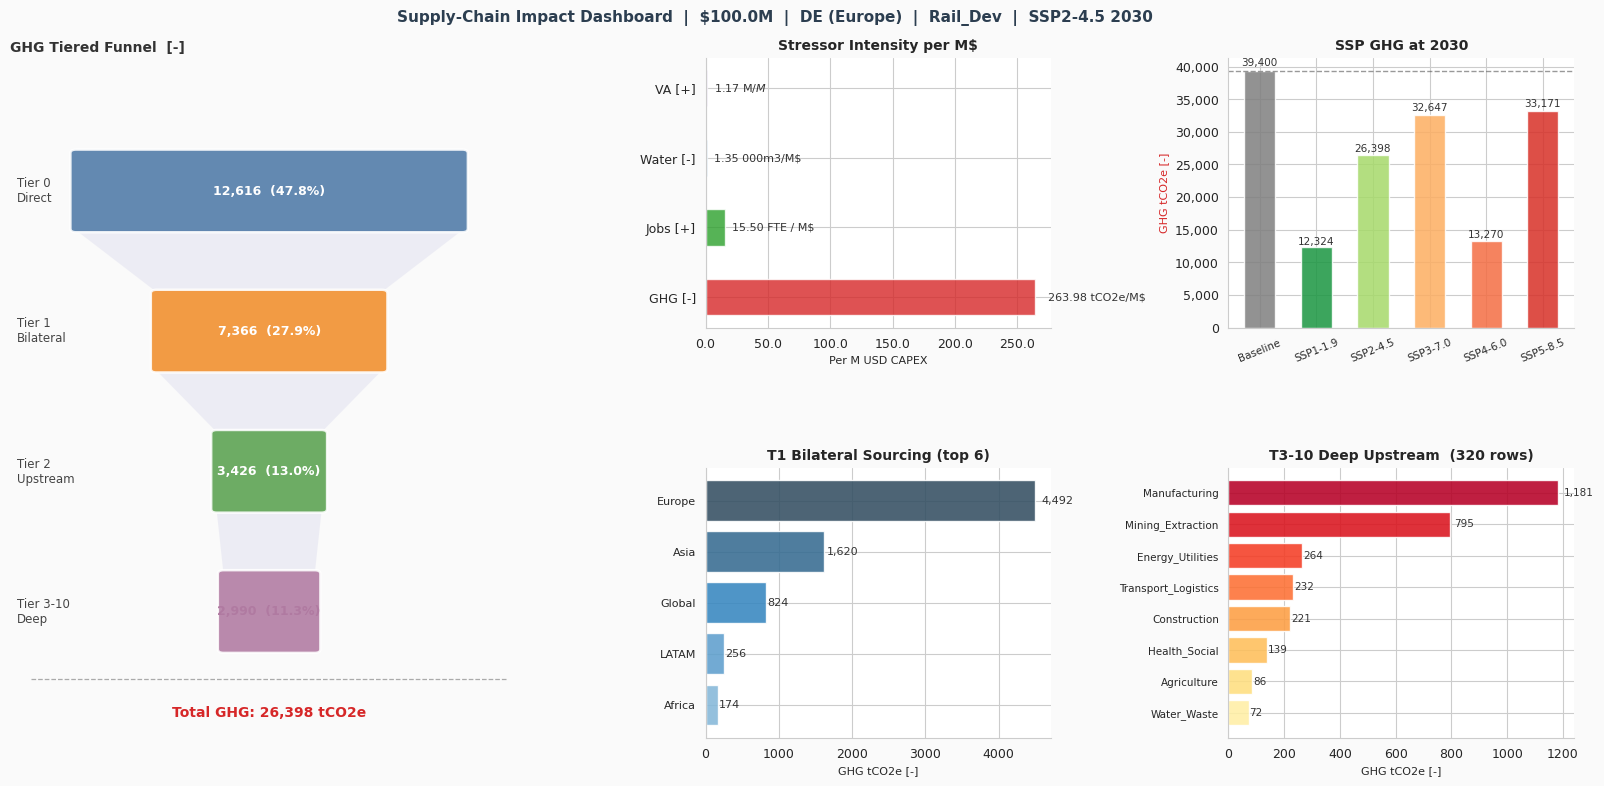

Dashboard saved -> results/dashboard_Rail_Dev_Europe_100p0M_SSP245.png


In [12]:
# ══════════════════════════════════════════════════════════════════
# SECTION 7 — STATIC SUMMARY DASHBOARD  (Matplotlib / Seaborn)
# Static tiered funnel + 4 panels — honest alternative to Sankey
# when >5 sourcing regions make the interactive view cluttered.
# ══════════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import Polygon, FancyBboxPatch
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
})

TIER_COLORS_MPL = ["#4e79a7", "#f28e2b", "#59a14f", "#b07aa1"]
SSP_COLORS_MPL  = {
    "SSP1-1.9": "#1a9641", "SSP2-4.5": "#a6d96a",
    "SSP3-7.0": "#fdae61", "SSP4-6.0": "#f46d43", "SSP5-8.5": "#d73027",
}

# ── Data prep ──────────────────────────────────────────────────────────────
_tier_labels = ["Tier 0\nDirect", "Tier 1\nBilateral",
                "Tier 2\nUpstream", "Tier 3-10\nDeep"]
_tier_dfs    = [t0, t1, t2, t3]
COLS_ALL     = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]

_tier_vals  = {}
_sc_totals  = {}

for _col in COLS_ALL:
    _v = [_apply(_df[_col].sum() if _col in _df.columns else 0, _col, FACTORS)
          for _df in _tier_dfs]
    _tier_vals[_col]  = _v
    _sc_totals[_col]  = sum(_v)

_capex_musd = CAPEX_USD / 1e6

# ── Figure layout ──────────────────────────────────────────────────────────
fig_dash = plt.figure(figsize=(17, 8), facecolor="#fafafa")
fig_dash.suptitle(
    (f"Supply-Chain Impact Dashboard  |  {fmt_capex(CAPEX_USD)}  |  "
     f"{COUNTRY} ({REGION})  |  {SECTOR}  |  {sc_label}"),
    fontsize=11, fontweight="bold", y=0.99, color="#2c3e50"
)

gs = gridspec.GridSpec(
    2, 3, figure=fig_dash,
    left=0.05, right=0.97, top=0.93, bottom=0.08,
    hspace=0.52, wspace=0.44,
    width_ratios=[1.5, 1, 1],
)

ax_funnel = fig_dash.add_subplot(gs[:, 0])
ax_kpi    = fig_dash.add_subplot(gs[0, 1])
ax_ssp    = fig_dash.add_subplot(gs[0, 2])
ax_bilat  = fig_dash.add_subplot(gs[1, 1])
ax_deep   = fig_dash.add_subplot(gs[1, 2])

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 1 — Tiered GHG Funnel
# Each tier is a centred horizontal bar; width proportional to GHG.
# Grey trapezia connect adjacent bars for the funnel-taper effect.
# ═══════════════════════════════════════════════════════════════════════════
_ghg_vals  = _tier_vals["GHG_tCO2e"]
_ghg_total = _sc_totals["GHG_tCO2e"]
_max_v     = max(abs(v) for v in _ghg_vals) or 1

n_tiers = len(_tier_labels)
y_pos   = list(range(n_tiers - 1, -1, -1))   # T0 at top

ax_funnel.set_xlim(-1.18, 1.18)
ax_funnel.set_ylim(-0.90, n_tiers - 0.05)
ax_funnel.axis("off")

half_widths = [(abs(v) / _max_v) * 0.88 for v in _ghg_vals]

# Trapezia
for i in range(n_tiers - 1):
    yi_top = y_pos[i]
    yi_bot = y_pos[i + 1]
    hw_hi  = half_widths[i]
    hw_lo  = half_widths[i + 1]
    trap = Polygon(
        [(-hw_hi, yi_top - 0.28), ( hw_hi, yi_top - 0.28),
         ( hw_lo, yi_bot + 0.28), (-hw_lo, yi_bot + 0.28)],
        closed=True, facecolor="#dde", edgecolor="none", alpha=0.45, zorder=0
    )
    ax_funnel.add_patch(trap)

# Rounded bars
for y, label, v, color, hw in zip(
        y_pos, _tier_labels, _ghg_vals, TIER_COLORS_MPL, half_widths):
    rect = FancyBboxPatch(
        (-hw, y - 0.27), 2 * hw, 0.54,
        boxstyle="round,pad=0.025",
        facecolor=color, edgecolor="white", linewidth=1.8,
        alpha=0.88, zorder=1
    )
    ax_funnel.add_patch(rect)

    pct     = v / _ghg_total * 100 if _ghg_total else 0
    txt_col = "white" if hw > 0.22 else color
    ax_funnel.text(0, y, f"{v:,.0f}  ({pct:.1f}%)",
                   ha="center", va="center",
                   fontsize=9, fontweight="bold", color=txt_col, zorder=2)
    ax_funnel.text(-1.15, y, label,
                   ha="left", va="center", fontsize=8.5, color="#444")

ax_funnel.axhline(-0.48, xmin=0.04, xmax=0.96,
                  color="#aaa", linewidth=0.9, linestyle="--")
ax_funnel.text(0, -0.72, f"Total GHG: {_ghg_total:,.0f} tCO2e",
               ha="center", va="center",
               fontsize=10, fontweight="bold", color="#d62728")
ax_funnel.set_title("GHG Tiered Funnel  [-]",
                    fontsize=10, fontweight="bold", pad=4, color="#333", loc="left")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 2 — Stressor Intensity per M USD CAPEX
# ═══════════════════════════════════════════════════════════════════════════
_smeta = [
    ("GHG_tCO2e",      "GHG [-]",  "tCO2e/M$",  "#d62728"),
    ("Employment_FTE", "Jobs [+]",  "FTE / M$",   "#2ca02c"),
    ("Water_1000m3",   "Water [-]", "000m3/M$",   "#1f77b4"),
    ("ValueAdded_M$",  "VA [+]",    "M$ / M$",    "#9467bd"),
]
_intens  = [_sc_totals[c] / _capex_musd for c, *_ in _smeta]
_klabels = [m[1] for m in _smeta]
_kcolors = [m[3] for m in _smeta]
_kunits  = [m[2] for m in _smeta]

_bk = ax_kpi.barh(_klabels, _intens, color=_kcolors,
                   alpha=0.80, edgecolor="white", height=0.52)
for _b, _val, _unit in zip(_bk, _intens, _kunits):
    ax_kpi.text(_b.get_width() * 1.02,
                _b.get_y() + _b.get_height() / 2,
                f"  {_val:,.2f} {_unit}",
                va="center", fontsize=8, color="#333")
ax_kpi.set_xlabel("Per M USD CAPEX", fontsize=8)
ax_kpi.set_title("Stressor Intensity per M$", fontsize=10, fontweight="bold")
ax_kpi.tick_params(axis="y", labelsize=9)
ax_kpi.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.1f}"))
ax_kpi.spines[["top", "right"]].set_visible(False)

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 3 — SSP GHG Comparison
# ═══════════════════════════════════════════════════════════════════════════
_ssps_ok = [s for s in ALL_SSPS if ALL_FACTORS.get(s)]

if COMPARE_SSPS and _ssps_ok:
    def _tot(col, f):
        return sum(_apply(_df[col].sum() if col in _df.columns else 0, col, f)
                   for _df in _tier_dfs)

    _ssp_lbl = ["Baseline"] + _ssps_ok
    _ssp_ghg = [_tot("GHG_tCO2e", None)] + \
               [_tot("GHG_tCO2e", ALL_FACTORS[s]) for s in _ssps_ok]
    _ssp_clr = ["#7f7f7f"] + [SSP_COLORS_MPL[s] for s in _ssps_ok]

    _bs = ax_ssp.bar(_ssp_lbl, _ssp_ghg, color=_ssp_clr,
                     alpha=0.85, edgecolor="white", width=0.55)
    for _b, _val in zip(_bs, _ssp_ghg):
        ax_ssp.text(_b.get_x() + _b.get_width() / 2,
                    _b.get_height() * 1.01,
                    f"{_val:,.0f}", ha="center", va="bottom",
                    fontsize=7.5, color="#333")
    ax_ssp.axhline(_ssp_ghg[0], color="#555", linewidth=1,
                   linestyle="--", alpha=0.6)
    ax_ssp.set_ylabel("GHG tCO2e [-]", fontsize=8, color="#d62728")
    ax_ssp.set_title(f"SSP GHG at {FOCUS_YEAR}", fontsize=10, fontweight="bold")
    ax_ssp.tick_params(axis="x", labelsize=7.5, rotation=22)
    ax_ssp.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax_ssp.spines[["top", "right"]].set_visible(False)
else:
    ax_ssp.text(0.5, 0.5, "No scenario\ndata available",
                ha="center", va="center",
                transform=ax_ssp.transAxes, fontsize=11, color="#aaa")
    ax_ssp.set_title("SSP Comparison", fontsize=10, fontweight="bold")
    ax_ssp.axis("off")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 4 — Tier 1 Bilateral Sourcing  (top 6 regions by GHG)
# ═══════════════════════════════════════════════════════════════════════════
_bilat = (t1.groupby("sourcing_region")["GHG_tCO2e"]
            .sum()
            .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
            .sort_values(ascending=True)
            .tail(6))

if not _bilat.empty and _bilat.sum() > 0:
    _bc = sns.color_palette("Blues_d", len(_bilat))
    ax_bilat.barh(_bilat.index, _bilat.values, color=_bc,
                  alpha=0.88, edgecolor="white")
    for _i, (_n, _val) in enumerate(_bilat.items()):
        ax_bilat.text(_val * 1.02, _i, f"{_val:,.0f}",
                      va="center", fontsize=8, color="#333")
    ax_bilat.set_xlabel("GHG tCO2e [-]", fontsize=8)
    ax_bilat.set_title("T1 Bilateral Sourcing (top 6)", fontsize=10, fontweight="bold")
    ax_bilat.tick_params(axis="y", labelsize=8)
    ax_bilat.spines[["top", "right"]].set_visible(False)
else:
    ax_bilat.text(0.5, 0.5, "No T1 GHG data",
                  ha="center", va="center", transform=ax_bilat.transAxes, color="#aaa")
    ax_bilat.axis("off")

# ═══════════════════════════════════════════════════════════════════════════
# PANEL 5 — Deep Upstream T3-10  (top 8 sectors by GHG)
# ═══════════════════════════════════════════════════════════════════════════
if "GHG_tCO2e" in t3.columns and t3["GHG_tCO2e"].sum() > 0:
    _deep = (t3.groupby("supplying_sector")["GHG_tCO2e"]
               .sum()
               .apply(lambda v: _apply(v, "GHG_tCO2e", FACTORS))
               .sort_values(ascending=True)
               .tail(8))
    _dc = sns.color_palette("YlOrRd", len(_deep))
    ax_deep.barh(_deep.index, _deep.values, color=_dc,
                 alpha=0.88, edgecolor="white")
    for _i, (_n, _val) in enumerate(_deep.items()):
        ax_deep.text(_val * 1.02, _i, f"{_val:,.0f}",
                     va="center", fontsize=7.5, color="#333")
    ax_deep.set_xlabel("GHG tCO2e [-]", fontsize=8)
    ax_deep.set_title(
        f"T3-10 Deep Upstream  ({len(t3)} rows)",
        fontsize=10, fontweight="bold"
    )
    ax_deep.tick_params(axis="y", labelsize=7.5)
    ax_deep.spines[["top", "right"]].set_visible(False)
else:
    ax_deep.text(0.5, 0.5, "No T3-10\nGHG data",
                 ha="center", va="center", transform=ax_deep.transAxes, color="#aaa")
    ax_deep.axis("off")

# ── Save + display ─────────────────────────────────────────────────────────
_slug = (f"dashboard_{SECTOR}_{REGION}_"
         f"{fmt_capex(CAPEX_USD).replace('$','').replace('.','p')}"
         f"{'_'+SCENARIO.replace('.','').replace('-','') if SCENARIO else ''}.png")
RESULTS_DIR.mkdir(exist_ok=True)
fig_dash.savefig(RESULTS_DIR / _slug, dpi=150,
                 bbox_inches="tight", facecolor="#fafafa")
plt.tight_layout()
plt.show()
print(f"Dashboard saved -> results/{_slug}")
